# Q-Med Colcabamba - Fase 2: análisis geoespacial y red vial [VERSIÓN CORREGIDA]

**Objetivo:** representar las IPRESS de la **Microrred Colcabamba** como nodos equivalentes, validar sus coordenadas y construir costos de viaje por la red de carreteras.

En esta fase ninguna IPRESS se fija como depósito. La fuente logística se incorpora recién en la Fase 3 a partir de evidencia documental.

> **VERSIÓN CORREGIDA:** Haversine no es una distancia euclidiana plana, sino la separación geodésica directa sobre la Tierra. Se conserva únicamente como control; `distance_matrix.csv` y `duration_matrix.csv` se calculan sobre carreteras de OpenStreetMap mediante OSRM.

## Entradas y salidas

| Tipo | Archivo | Propósito |
|---|---|---|
| Entrada | `data/processed/ipress_colcabamba.csv` | IPRESS activas obtenidas en la Fase 1 |
| Salida principal | `data/optimization/distance_matrix.csv` | Distancias viales dirigidas en km |
| Salida principal | `data/optimization/duration_matrix.csv` | Tiempos viales estimados en minutos |
| Control | `data/optimization/distance_matrix_geodesic.csv` | Distancias Haversine |
| Salida | `data/optimization/distance_pairs.csv` | Comparación vial-geodésica por par |
| Visual | `outputs/maps/ipress_colcabamba_interactive.html` | Mapa con rutas viales reales de referencia |

El servicio de ruteo es [OSRM](https://project-osrm.org/) sobre datos de [OpenStreetMap](https://www.openstreetmap.org/copyright). Los tiempos son estimaciones del motor de ruteo, no mediciones de tráfico en tiempo real.

In [1]:
from __future__ import annotations

import html
import json
import os
import re
import unicodedata
from pathlib import Path
from urllib.request import Request, urlopen

os.environ.setdefault("MPLCONFIGDIR", "/tmp/qmed-matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "navy": "#17324D",
    "teal": "#0F766E",
    "blue": "#2563EB",
    "orange": "#EA580C",
    "purple": "#7C3AED",
    "slate": "#64748B",
    "light": "#E2E8F0",
}
CATEGORY_COLORS = {
    "I-1": COLORS["teal"],
    "I-2": COLORS["orange"],
    "I-3": COLORS["blue"],
    "I-4": COLORS["purple"],
    "SIN CATEGORÍA": COLORS["slate"],
}

mkdir -p failed for path O:\tmp\qmed-matplotlib: [WinError 2] El sistema no puede encontrar el archivo especificado: 'O:\\tmp'
Matplotlib created a temporary cache directory at C:\Users\guill\AppData\Local\Temp\matplotlib-v29j7bzc because there was an issue with the default path (O:\tmp\qmed-matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def locate_repo_root(start: Path | None = None) -> Path:
    configured_root = os.getenv("QMED_REPO_ROOT")
    if configured_root:
        root = Path(configured_root).expanduser().resolve()
        if not (root / "data").exists():
            raise FileNotFoundError(f"QMED_REPO_ROOT={root} no contiene data/.")
        return root

    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró la raíz del repositorio. Define QMED_REPO_ROOT."
    )


REPO_ROOT = locate_repo_root()
INPUT_PATH = REPO_ROOT / "data" / "processed" / "ipress_colcabamba.csv"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
OPTIMIZATION_DIR = REPO_ROOT / "data" / "optimization"
FIGURES_DIR = REPO_ROOT / "outputs" / "figures"
MAPS_DIR = REPO_ROOT / "outputs" / "maps"

for directory in [PROCESSED_DIR, OPTIMIZATION_DIR, FIGURES_DIR, MAPS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PILOT_MICRORED = "COLCABAMBA"
EARTH_RADIUS_KM = 6371.0088
OSRM_BASE_URL = "https://router.project-osrm.org"
OSRM_PROFILE = "driving"
MAX_SNAP_DISTANCE_M = 250.0

print(f"Raíz del proyecto: {REPO_ROOT}")
print(f"Entrada: {INPUT_PATH}")

Raíz del proyecto: O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte
Entrada: O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\processed\ipress_colcabamba.csv


## 1. Alcance y control de calidad

La Fase 1 conserva diez IPRESS del distrito. El piloto usa las siete que pertenecen administrativamente a la **Microrred Colcabamba**. Este filtro decide qué establecimientos participan, pero no asigna un origen.

In [3]:
REQUIRED_COLUMNS = {
    "COD_IPRESS", "NOMBRE", "CATEGORIA", "LATITUD", "LONGITUD",
    "MICRORED", "RED", "INSTITUCION", "TIPO_ESTABLECIMIENTO",
}


def canonical_text(value: object) -> str:
    if pd.isna(value):
        return ""
    normalized = unicodedata.normalize("NFKD", str(value))
    normalized = "".join(
        char for char in normalized if not unicodedata.combining(char)
    )
    return re.sub(r"\s+", " ", normalized).strip().upper()


if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"No existe {INPUT_PATH}. Ejecuta primero 01_data_cleaning.ipynb."
    )

district_ipress = pd.read_csv(
    INPUT_PATH,
    encoding="utf-8-sig",
    dtype={"COD_IPRESS": "string"},
)
missing = REQUIRED_COLUMNS.difference(district_ipress.columns)
if missing:
    raise ValueError("Faltan columnas: " + ", ".join(sorted(missing)))

district_ipress["COD_IPRESS"] = (
    district_ipress["COD_IPRESS"].str.replace(r"\.0$", "", regex=True).str.strip()
)
district_ipress["MICRORED_CANONICAL"] = district_ipress["MICRORED"].map(
    canonical_text
)
in_scope = district_ipress["MICRORED_CANONICAL"].eq(
    canonical_text(PILOT_MICRORED)
)
ipress = district_ipress.loc[in_scope].copy()
exclusions = district_ipress.loc[~in_scope].copy()
exclusions["EXCLUSION_REASON"] = (
    "Fuera del alcance: MICRORED distinta de COLCABAMBA"
)
exclusions_path = PROCESSED_DIR / "scope_exclusions.csv"
exclusions.drop(columns="MICRORED_CANONICAL").to_csv(
    exclusions_path, index=False, encoding="utf-8-sig"
)

for column in ["LATITUD", "LONGITUD"]:
    ipress[column] = pd.to_numeric(ipress[column], errors="coerce")

if len(ipress) < 2:
    raise ValueError("Se requieren al menos dos IPRESS.")
if ipress["COD_IPRESS"].duplicated().any():
    raise ValueError("COD_IPRESS no es único dentro de la microrred.")
if ipress[["LATITUD", "LONGITUD"]].isna().any().any():
    raise ValueError("Existen coordenadas faltantes o no numéricas.")
if not ipress["LATITUD"].between(-18.5, 0).all():
    raise ValueError("Existen latitudes fuera de Perú.")
if not ipress["LONGITUD"].between(-82, -68).all():
    raise ValueError("Existen longitudes fuera de Perú.")
if ipress.duplicated(["LATITUD", "LONGITUD"]).any():
    raise ValueError("Existen coordenadas duplicadas.")

print(f"IPRESS del distrito: {len(district_ipress)}")
print(f"IPRESS incluidas: {len(ipress)}")
print(f"Exclusiones auditadas: {len(exclusions)}")
display(
    ipress[
        ["COD_IPRESS", "NOMBRE", "CATEGORIA", "MICRORED", "LATITUD", "LONGITUD"]
    ].sort_values("COD_IPRESS")
)

IPRESS del distrito: 10
IPRESS incluidas: 7
Exclusiones auditadas: 3


,COD_IPRESS,NOMBRE,CATEGORIA,MICRORED,LATITUD,LONGITUD
0,00004090,COLCABAMBA,I-4,COLCABAMBA,-12.408,-74.681
1,00004092,CARPAPATA,I-2,COLCABAMBA,-12.388,-74.750
2,00004093,POCCYACC,I-1,COLCABAMBA,-12.478,-74.650
3,00004094,OCORO,I-2,COLCABAMBA,-12.350,-74.728
4,00004095,TOCAS,I-2,COLCABAMBA,-12.443,-74.653
6,00007387,CHACHAS,I-1,COLCABAMBA,-12.428,-74.619
8,00012900,RANRA,I-1,COLCABAMBA,-12.341,-74.743


## 2. Construcción neutral de nodos

Los identificadores `IP01`, `IP02`, ... fijan un orden estable. No representan jerarquía ni depósito.

In [4]:
ipress["COD_IPRESS_NUMERIC"] = pd.to_numeric(
    ipress["COD_IPRESS"], errors="coerce"
)
if ipress["COD_IPRESS_NUMERIC"].isna().any():
    raise ValueError("Todos los COD_IPRESS deben ser numéricos.")

ordered = (
    ipress.sort_values(["COD_IPRESS_NUMERIC", "NOMBRE"], kind="stable")
    .reset_index(drop=True)
    .copy()
)
ordered["NODE_ORDER"] = np.arange(len(ordered), dtype=int)
ordered["NODE_ID"] = [
    f"IP{position:02d}" for position in range(1, len(ordered) + 1)
]
node_columns = [
    "NODE_ID", "NODE_ORDER", "COD_IPRESS", "NOMBRE", "CATEGORIA",
    "LATITUD", "LONGITUD", "INSTITUCION", "TIPO_ESTABLECIMIENTO",
    "RED", "MICRORED",
]
nodes = ordered[node_columns].copy()
display(nodes)

,NODE_ID,NODE_ORDER,COD_IPRESS,NOMBRE,CATEGORIA,LATITUD,LONGITUD,INSTITUCION,TIPO_ESTABLECIMIENTO,RED,MICRORED
0,IP01,0,00004090,COLCABAMBA,I-4,-12.408,-74.681,GOBIERNO REGIONAL,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,TAYACAJA,COLCABAMBA
1,IP02,1,00004092,CARPAPATA,I-2,-12.388,-74.750,GOBIERNO REGIONAL,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,TAYACAJA,COLCABAMBA
2,IP03,2,00004093,POCCYACC,I-1,-12.478,-74.650,GOBIERNO REGIONAL,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,TAYACAJA,COLCABAMBA
3,IP04,3,00004094,OCORO,I-2,-12.350,-74.728,GOBIERNO REGIONAL,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,TAYACAJA,COLCABAMBA
4,IP05,4,00004095,TOCAS,I-2,-12.443,-74.653,GOBIERNO REGIONAL,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,TAYACAJA,COLCABAMBA
5,IP06,5,00007387,CHACHAS,I-1,-12.428,-74.619,GOBIERNO REGIONAL,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,TAYACAJA,COLCABAMBA
6,IP07,6,00012900,RANRA,I-1,-12.341,-74.743,GOBIERNO REGIONAL,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,TAYACAJA,COLCABAMBA


## 3. Distancia geodésica frente a distancia vial

Haversine calcula la separación directa:

$a=\sin^2(\Delta\varphi/2)+\cos(\varphi_1)\cos(\varphi_2)\sin^2(\Delta\lambda/2)$

$d_{geo}=2R\arcsin(\sqrt{a})$

Para el costo logístico se consulta la red vial. La matriz de OSRM puede ser asimétrica, por lo que se conserva el sentido origen-destino. La relación

$\rho_{ij}=d_{vial,ij}/d_{geo,ij}$

permite observar cuánto subestimaba la separación directa.

In [5]:
def fetch_json(url: str, timeout: int = 90) -> dict:
    request = Request(
        url,
        headers={"User-Agent": "QMed-Colcabamba-Hackathon/1.0"},
    )
    with urlopen(request, timeout=timeout) as response:
        return json.load(response)


def haversine_matrix(
    latitudes: np.ndarray,
    longitudes: np.ndarray,
    radius_km: float = EARTH_RADIUS_KM,
) -> np.ndarray:
    lat = np.radians(np.asarray(latitudes, dtype=float))
    lon = np.radians(np.asarray(longitudes, dtype=float))
    delta_lat = lat[:, None] - lat[None, :]
    delta_lon = lon[:, None] - lon[None, :]
    a = (
        np.sin(delta_lat / 2.0) ** 2
        + np.cos(lat[:, None])
        * np.cos(lat[None, :])
        * np.sin(delta_lon / 2.0) ** 2
    )
    a = np.clip(a, 0.0, 1.0)
    result = 2.0 * radius_km * np.arcsin(np.sqrt(a))
    np.fill_diagonal(result, 0.0)
    return result


def osrm_table(node_frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    coordinates = ";".join(
        f"{row.LONGITUD:.8f},{row.LATITUD:.8f}"
        for row in node_frame.itertuples(index=False)
    )
    url = (
        f"{OSRM_BASE_URL}/table/v1/{OSRM_PROFILE}/{coordinates}"
        "?annotations=distance,duration"
    )
    payload = fetch_json(url)
    if payload.get("code") != "Ok":
        raise RuntimeError(f"OSRM no devolvió una tabla válida: {payload}")
    if any(value is None for row in payload["distances"] for value in row):
        raise RuntimeError("OSRM encontró pares sin conexión vial.")

    distances_km = np.asarray(payload["distances"], dtype=float) / 1000.0
    durations_min = np.asarray(payload["durations"], dtype=float) / 60.0
    snap_distances_m = np.asarray(
        [source["distance"] for source in payload["sources"]],
        dtype=float,
    )
    return distances_km, durations_min, snap_distances_m


def osrm_route(
    origin_lat: float,
    origin_lon: float,
    destination_lat: float,
    destination_lon: float,
) -> dict:
    coordinates = (
        f"{origin_lon:.8f},{origin_lat:.8f};"
        f"{destination_lon:.8f},{destination_lat:.8f}"
    )
    url = (
        f"{OSRM_BASE_URL}/route/v1/{OSRM_PROFILE}/{coordinates}"
        "?overview=full&geometries=geojson&steps=false"
    )
    payload = fetch_json(url)
    if payload.get("code") != "Ok" or not payload.get("routes"):
        raise RuntimeError(f"OSRM no encontró ruta: {payload}")
    route = payload["routes"][0]
    return {
        "DISTANCE_KM": route["distance"] / 1000.0,
        "DURATION_MIN": route["duration"] / 60.0,
        "LATLON": [
            [latitude, longitude]
            for longitude, latitude in route["geometry"]["coordinates"]
        ],
    }

In [6]:
node_ids = nodes["NODE_ID"].tolist()
geodesic_values = haversine_matrix(
    nodes["LATITUD"].to_numpy(),
    nodes["LONGITUD"].to_numpy(),
)
road_distance_values, duration_values, snap_distances_m = osrm_table(nodes)

geodesic_matrix = pd.DataFrame(
    geodesic_values, index=node_ids, columns=node_ids
)
road_distance_matrix = pd.DataFrame(
    road_distance_values, index=node_ids, columns=node_ids
)
duration_matrix = pd.DataFrame(
    duration_values, index=node_ids, columns=node_ids
)
for frame in [geodesic_matrix, road_distance_matrix, duration_matrix]:
    frame.index.name = "NODE_ID"

pairs = []
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        road_mean = float(
            (road_distance_values[i, j] + road_distance_values[j, i]) / 2
        )
        time_mean = float((duration_values[i, j] + duration_values[j, i]) / 2)
        direct = float(geodesic_values[i, j])
        pairs.append(
            {
                "NODE_A_ID": nodes.loc[i, "NODE_ID"],
                "NODE_A_NAME": nodes.loc[i, "NOMBRE"],
                "NODE_B_ID": nodes.loc[j, "NODE_ID"],
                "NODE_B_NAME": nodes.loc[j, "NOMBRE"],
                "GEODESIC_DISTANCE_KM": direct,
                "ROAD_DISTANCE_A_TO_B_KM": road_distance_values[i, j],
                "ROAD_DISTANCE_B_TO_A_KM": road_distance_values[j, i],
                "ROAD_DISTANCE_MEAN_KM": road_mean,
                "DURATION_A_TO_B_MIN": duration_values[i, j],
                "DURATION_B_TO_A_MIN": duration_values[j, i],
                "DURATION_MEAN_MIN": time_mean,
                "DETOUR_RATIO": road_mean / direct,
            }
        )
distance_pairs = pd.DataFrame(pairs).sort_values(
    "ROAD_DISTANCE_MEAN_KM", kind="stable"
)

snap_report = nodes[["NODE_ID", "NOMBRE"]].copy()
snap_report["OSRM_SNAP_DISTANCE_M"] = snap_distances_m

print(f"Matriz vial: {road_distance_matrix.shape}")
print(f"Pares únicos: {len(distance_pairs)}")
display(road_distance_matrix.round(2))
print("Comparación entre carretera y Haversine")
display(
    distance_pairs[
        [
            "NODE_A_NAME", "NODE_B_NAME", "GEODESIC_DISTANCE_KM",
            "ROAD_DISTANCE_MEAN_KM", "DURATION_MEAN_MIN", "DETOUR_RATIO",
        ]
    ].round(2)
)

Matriz vial: (7, 7)
Pares únicos: 21


,IP01,IP02,IP03,IP04,IP05,IP06,IP07
NODE_ID,,,,,,,
IP01,0.000,24.420,17.580,25.740,8.990,25.490,32.110
IP02,24.420,0.000,41.760,21.470,33.180,49.670,18.910
IP03,17.580,41.760,0.000,43.080,9.170,21.440,49.450
IP04,25.740,21.470,43.080,0.000,34.500,50.990,7.260
IP05,8.990,33.180,9.170,34.500,0.000,20.900,40.870
IP06,25.490,49.670,21.440,50.990,20.900,0.000,57.360
IP07,32.110,18.910,49.450,7.260,40.870,57.360,0.000


Comparación entre carretera y Haversine


,NODE_A_NAME,NODE_B_NAME,GEODESIC_DISTANCE_KM,ROAD_DISTANCE_MEAN_KM,DURATION_MEAN_MIN,DETOUR_RATIO
17,OCORO,RANRA,1.900,7.260,11.560,3.820
3,COLCABAMBA,TOCAS,4.900,8.990,10.680,1.840
12,POCCYACC,TOCAS,3.930,9.170,12.730,2.330
1,COLCABAMBA,POCCYACC,8.420,17.580,21.650,2.090
10,CARPAPATA,RANRA,5.340,18.910,29.920,3.540
18,TOCAS,CHACHAS,4.050,20.900,31.860,5.160
13,POCCYACC,CHACHAS,6.540,21.440,31.960,3.280
7,CARPAPATA,OCORO,4.830,21.470,32.040,4.440
0,COLCABAMBA,CARPAPATA,7.760,24.420,30.510,3.150
4,COLCABAMBA,CHACHAS,7.140,25.490,38.920,3.570


## 4. Lecturas descriptivas y red vial mínima

Se calculan el vecino vial más cercano, la distancia vial promedio y una red de expansión mínima (MST) construida con el promedio de ambos sentidos. La MST es solo una representación compacta de conectividad; no es una ruta de reparto.

In [7]:
masked = road_distance_values.copy()
np.fill_diagonal(masked, np.inf)
nearest_indices = masked.argmin(axis=1)
nearest_neighbors = pd.DataFrame(
    {
        "NODE_ID": nodes["NODE_ID"],
        "NOMBRE": nodes["NOMBRE"],
        "NEAREST_NODE_ID": [
            nodes.loc[index, "NODE_ID"] for index in nearest_indices
        ],
        "NEAREST_NAME": [
            nodes.loc[index, "NOMBRE"] for index in nearest_indices
        ],
        "NEAREST_ROAD_DISTANCE_KM": [
            masked[row, nearest_indices[row]] for row in range(len(nodes))
        ],
        "NEAREST_DURATION_MIN": [
            duration_values[row, nearest_indices[row]]
            for row in range(len(nodes))
        ],
    }
).sort_values("NEAREST_ROAD_DISTANCE_KM")

distance_profile = nodes[
    ["NODE_ID", "COD_IPRESS", "NOMBRE", "CATEGORIA"]
].copy()
distance_profile["MEAN_ROAD_DISTANCE_KM"] = (
    road_distance_values.sum(axis=1) / (len(nodes) - 1)
)
distance_profile = distance_profile.sort_values(
    "MEAN_ROAD_DISTANCE_KM", kind="stable"
)


def minimum_spanning_tree(distances: np.ndarray) -> pd.DataFrame:
    n_nodes = len(distances)
    visited = {0}
    edges = []
    while len(visited) < n_nodes:
        candidates = [
            (float(distances[i, j]), i, j)
            for i in sorted(visited)
            for j in range(n_nodes)
            if j not in visited
        ]
        distance_km, origin_index, destination_index = min(candidates)
        edges.append(
            {
                "NODE_A_ID": nodes.loc[origin_index, "NODE_ID"],
                "NODE_A_NAME": nodes.loc[origin_index, "NOMBRE"],
                "NODE_B_ID": nodes.loc[destination_index, "NODE_ID"],
                "NODE_B_NAME": nodes.loc[destination_index, "NOMBRE"],
                "ROAD_DISTANCE_KM": distance_km,
            }
        )
        visited.add(destination_index)
    return pd.DataFrame(edges)


undirected_road = (road_distance_values + road_distance_values.T) / 2
mst_edges = minimum_spanning_tree(undirected_road)
node_lookup = nodes.set_index("NODE_ID")
mst_route_geometries = {}
for edge in mst_edges.itertuples(index=False):
    origin = node_lookup.loc[edge.NODE_A_ID]
    destination = node_lookup.loc[edge.NODE_B_ID]
    route = osrm_route(
        origin["LATITUD"], origin["LONGITUD"],
        destination["LATITUD"], destination["LONGITUD"],
    )
    mst_route_geometries[(edge.NODE_A_ID, edge.NODE_B_ID)] = route["LATLON"]

display(nearest_neighbors.round(2))
display(distance_profile.round(2))
print(
    "Longitud vial total de la MST: "
    f"{mst_edges['ROAD_DISTANCE_KM'].sum():.2f} km"
)

,NODE_ID,NOMBRE,NEAREST_NODE_ID,NEAREST_NAME,NEAREST_ROAD_DISTANCE_KM,NEAREST_DURATION_MIN
3,IP04,OCORO,IP07,RANRA,7.260,11.560
6,IP07,RANRA,IP04,OCORO,7.260,11.550
4,IP05,TOCAS,IP01,COLCABAMBA,8.990,10.610
0,IP01,COLCABAMBA,IP05,TOCAS,8.990,10.760
2,IP03,POCCYACC,IP05,TOCAS,9.170,12.780
1,IP02,CARPAPATA,IP07,RANRA,18.910,30.010
5,IP06,CHACHAS,IP05,TOCAS,20.900,31.870


,NODE_ID,COD_IPRESS,NOMBRE,CATEGORIA,MEAN_ROAD_DISTANCE_KM
0,IP01,00004090,COLCABAMBA,I-4,22.390
4,IP05,00004095,TOCAS,I-2,24.600
2,IP03,00004093,POCCYACC,I-1,30.410
3,IP04,00004094,OCORO,I-2,30.510
1,IP02,00004092,CARPAPATA,I-2,31.570
6,IP07,00012900,RANRA,I-1,34.330
5,IP06,00007387,CHACHAS,I-1,37.640


Longitud vial total de la MST: 89.66 km


## 5. Visualizaciones

Las curvas del mapa siguen geometrías viales devueltas por OSRM. Ya no se dibujan segmentos rectos que puedan confundirse con carreteras.

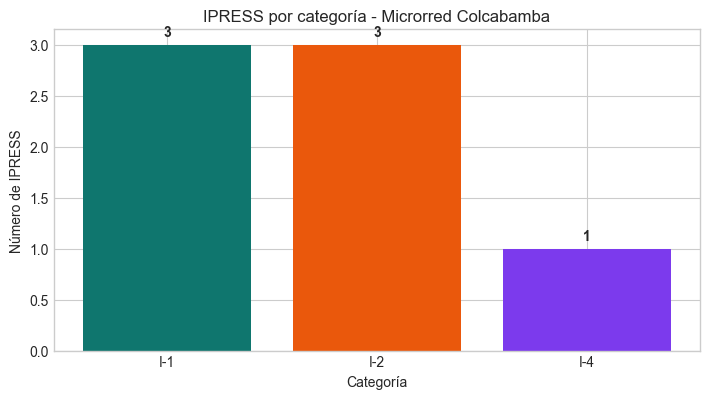

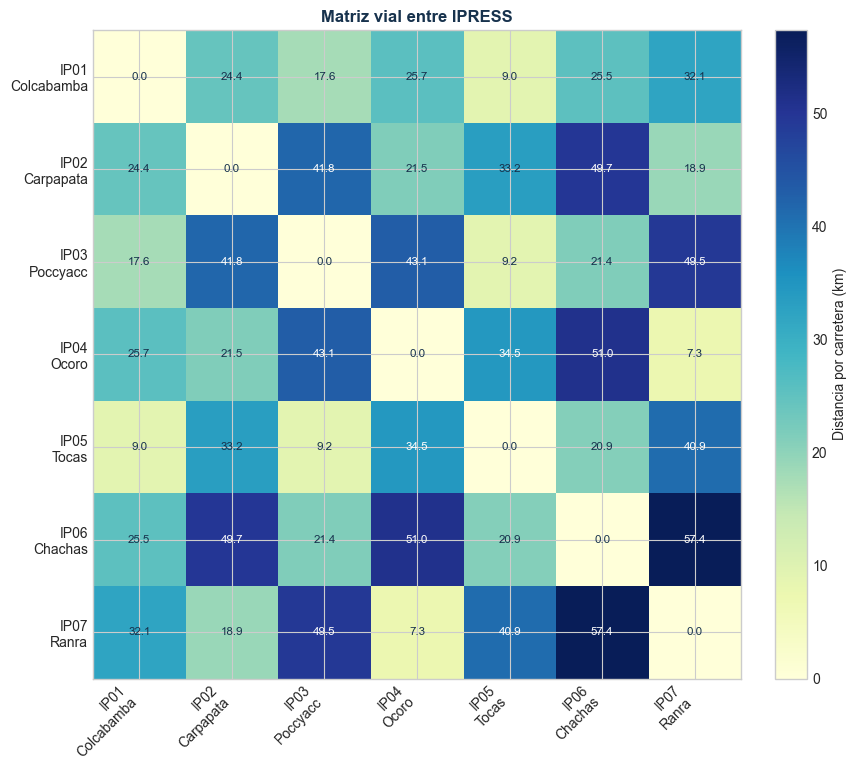

In [8]:
category_counts = (
    nodes["CATEGORIA"].fillna("SIN CATEGORÍA").value_counts().sort_index()
)
fig, ax = plt.subplots(figsize=(7.2, 4.1))
bars = ax.bar(
    category_counts.index,
    category_counts.values,
    color=[
        CATEGORY_COLORS.get(category, COLORS["slate"])
        for category in category_counts.index
    ],
)
ax.bar_label(bars, padding=4, fontweight="bold")
ax.set_title("IPRESS por categoría - Microrred Colcabamba")
ax.set_xlabel("Categoría")
ax.set_ylabel("Número de IPRESS")
fig.tight_layout()
category_path = FIGURES_DIR / "category_distribution.png"
fig.savefig(category_path, dpi=180, bbox_inches="tight")
plt.show()

labels = [
    f"{row.NODE_ID}\n{str(row.NOMBRE).title()}"
    for row in nodes.itertuples(index=False)
]
fig, ax = plt.subplots(figsize=(9.3, 7.8))
image = ax.imshow(road_distance_values, cmap="YlGnBu")
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
threshold = float(road_distance_values.max()) * 0.58
for i in range(len(nodes)):
    for j in range(len(nodes)):
        ax.text(
            j, i, f"{road_distance_values[i, j]:.1f}",
            ha="center", va="center", fontsize=8.4,
            color="white" if road_distance_values[i, j] > threshold else COLORS["navy"],
        )
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Distancia por carretera (km)")
ax.set_title("Matriz vial entre IPRESS", fontweight="bold", color=COLORS["navy"])
fig.tight_layout()
matrix_figure_path = FIGURES_DIR / "distance_matrix.png"
fig.savefig(matrix_figure_path, dpi=190, bbox_inches="tight")
plt.show()

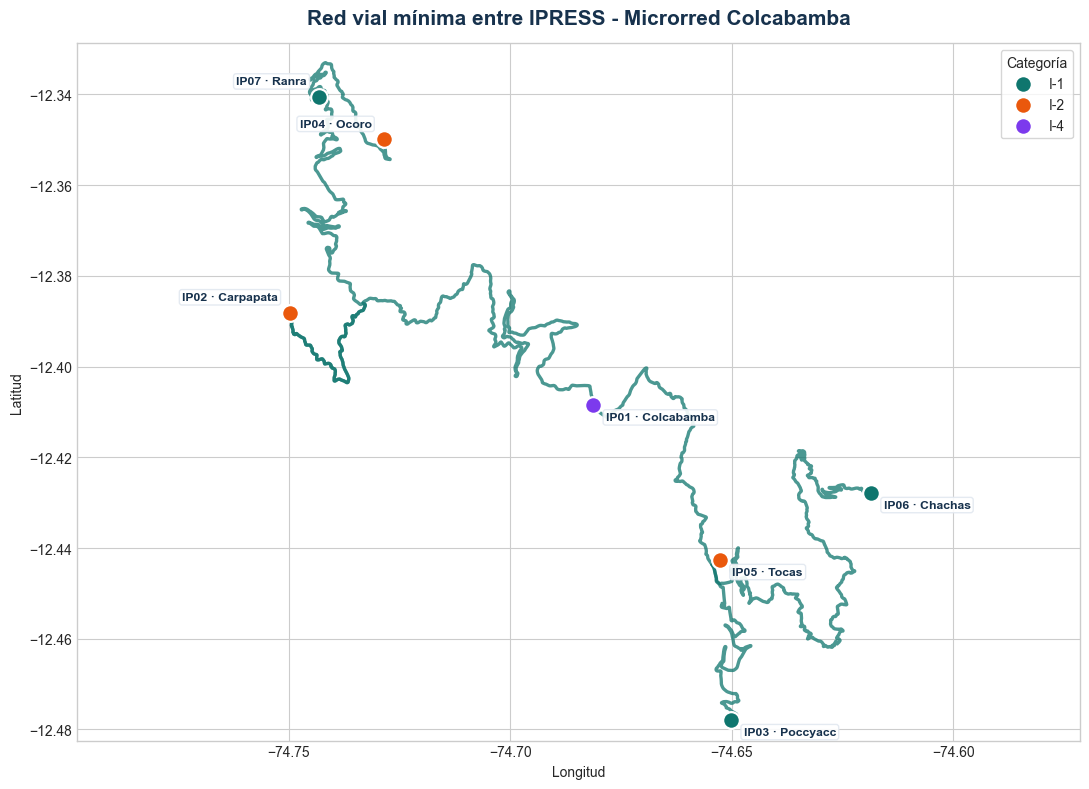

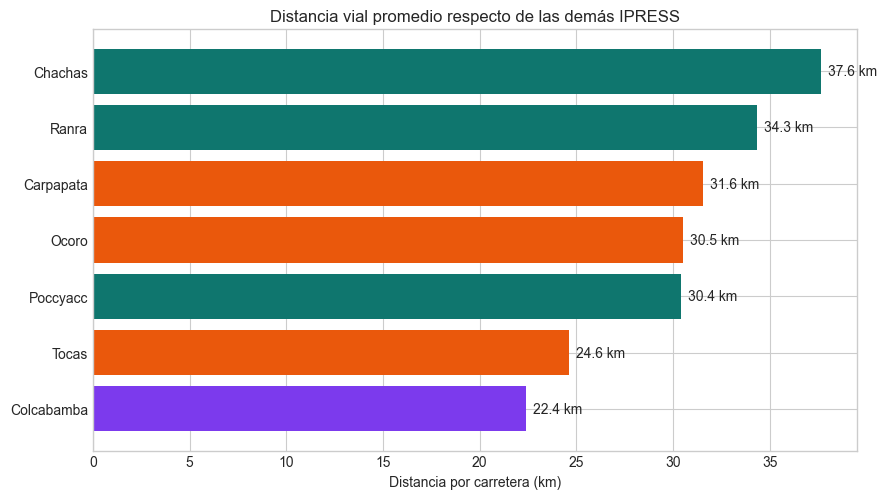

In [9]:
fig, ax = plt.subplots(figsize=(11, 8))
for edge in mst_edges.itertuples(index=False):
    route_points = np.asarray(
        mst_route_geometries[(edge.NODE_A_ID, edge.NODE_B_ID)]
    )
    ax.plot(
        route_points[:, 1], route_points[:, 0],
        color=COLORS["teal"], linewidth=2.4, alpha=0.75, zorder=1,
    )

for category, group in nodes.assign(
    CATEGORIA=nodes["CATEGORIA"].fillna("SIN CATEGORÍA")
).groupby("CATEGORIA"):
    ax.scatter(
        group["LONGITUD"], group["LATITUD"], s=145,
        color=CATEGORY_COLORS.get(category, COLORS["slate"]),
        edgecolor="white", linewidth=1.6, label=category, zorder=3,
    )

center_lon = nodes["LONGITUD"].mean()
center_lat = nodes["LATITUD"].mean()
for row in nodes.itertuples(index=False):
    x_offset = 9 if row.LONGITUD >= center_lon else -9
    y_offset = 9 if row.LATITUD >= center_lat else -11
    ax.annotate(
        f"{row.NODE_ID} · {str(row.NOMBRE).title()}",
        (row.LONGITUD, row.LATITUD),
        xytext=(x_offset, y_offset), textcoords="offset points",
        ha="left" if x_offset > 0 else "right",
        fontsize=8.8, fontweight="semibold", color=COLORS["navy"],
        bbox={"boxstyle": "round,pad=0.22", "fc": "white",
              "ec": COLORS["light"], "alpha": 0.9},
        zorder=4,
    )

ax.set_title(
    "Red vial mínima entre IPRESS - Microrred Colcabamba",
    fontsize=15, fontweight="bold", color=COLORS["navy"], pad=14,
)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(title="Categoría", frameon=True)
ax.set_aspect(
    1 / np.cos(np.radians(nodes["LATITUD"].mean())),
    adjustable="datalim",
)
fig.tight_layout()
spatial_map_path = FIGURES_DIR / "ipress_spatial_network.png"
fig.savefig(spatial_map_path, dpi=190, bbox_inches="tight")
plt.show()

profile_plot = distance_profile.sort_values("MEAN_ROAD_DISTANCE_KM")
fig, ax = plt.subplots(figsize=(9, 5.1))
bars = ax.barh(
    profile_plot["NOMBRE"].str.title(),
    profile_plot["MEAN_ROAD_DISTANCE_KM"],
    color=[
        CATEGORY_COLORS.get(category, COLORS["slate"])
        for category in profile_plot["CATEGORIA"].fillna("SIN CATEGORÍA")
    ],
)
ax.bar_label(bars, fmt="%.1f km", padding=5)
ax.set_title("Distancia vial promedio respecto de las demás IPRESS")
ax.set_xlabel("Distancia por carretera (km)")
fig.tight_layout()
average_distance_path = FIGURES_DIR / "average_distance_by_node.png"
fig.savefig(average_distance_path, dpi=190, bbox_inches="tight")
plt.show()

## 6. Mapa interactivo

El mapa muestra las siete IPRESS y la MST sobre carreteras. El centro inicial del visor es solo el promedio cartográfico de las coordenadas; no representa un depósito.

In [10]:
try:
    import folium
    from folium.plugins import Fullscreen, MeasureControl
    FOLIUM_AVAILABLE = True
except ModuleNotFoundError:
    FOLIUM_AVAILABLE = False
    print("Instala folium para generar el mapa interactivo.")

interactive_map_path = MAPS_DIR / "ipress_colcabamba_interactive.html"
if FOLIUM_AVAILABLE:
    interactive_map = folium.Map(
        location=[
            float(nodes["LATITUD"].mean()),
            float(nodes["LONGITUD"].mean()),
        ],
        zoom_start=11,
        tiles="CartoDB positron",
        control_scale=True,
    )
    road_layer = folium.FeatureGroup(name="Red vial mínima (OSRM)", show=True)
    marker_layer = folium.FeatureGroup(name="IPRESS", show=True)

    for edge in mst_edges.itertuples(index=False):
        geometry = mst_route_geometries[(edge.NODE_A_ID, edge.NODE_B_ID)]
        folium.PolyLine(
            locations=geometry,
            color=COLORS["teal"],
            weight=4,
            opacity=0.82,
            tooltip=(
                f"{str(edge.NODE_A_NAME).title()} ↔ "
                f"{str(edge.NODE_B_NAME).title()} · "
                f"{edge.ROAD_DISTANCE_KM:.1f} km por carretera"
            ),
        ).add_to(road_layer)

    for row in nodes.itertuples(index=False):
        category = row.CATEGORIA if pd.notna(row.CATEGORIA) else "SIN CATEGORÍA"
        popup_html = f"""
        <div style="font-family:Arial; min-width:240px; line-height:1.45">
          <b style="font-size:16px;color:#17324D">
            {html.escape(str(row.NOMBRE).title())}
          </b><br>
          <b>Nodo:</b> {html.escape(str(row.NODE_ID))}<br>
          <b>Código IPRESS:</b> {html.escape(str(row.COD_IPRESS))}<br>
          <b>Categoría:</b> {html.escape(str(category))}<br>
          <b>Coordenadas RENIPRESS:</b>
          {row.LATITUD:.6f}, {row.LONGITUD:.6f}
        </div>
        """
        folium.CircleMarker(
            location=[row.LATITUD, row.LONGITUD],
            radius=9, color="white", weight=2, fill=True,
            fill_color=CATEGORY_COLORS.get(category, COLORS["slate"]),
            fill_opacity=0.95,
            tooltip=f"{row.NODE_ID} · {str(row.NOMBRE).title()}",
            popup=folium.Popup(popup_html, max_width=330),
        ).add_to(marker_layer)

    road_layer.add_to(interactive_map)
    marker_layer.add_to(interactive_map)
    Fullscreen(position="topright").add_to(interactive_map)
    MeasureControl(
        position="topright",
        primary_length_unit="kilometers",
    ).add_to(interactive_map)
    folium.LayerControl(collapsed=False).add_to(interactive_map)
    interactive_map.fit_bounds(
        nodes[["LATITUD", "LONGITUD"]].values.tolist(),
        padding=(25, 25),
    )
    interactive_map.save(interactive_map_path)
    display(interactive_map)
    print(f"Mapa guardado: {interactive_map_path.relative_to(REPO_ROOT)}")

C:\Users\guill\AppData\Roaming\Python\Python312\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


Mapa guardado: outputs\maps\ipress_colcabamba_interactive.html


## 7. Exportación y controles de cierre

`distance_matrix.csv` pasa a ser la matriz vial que consumirá el optimizador. La matriz geodésica se exporta con nombre explícito y se usa solamente como control.

In [11]:
nodes_path = OPTIMIZATION_DIR / "nodes.csv"
distance_matrix_path = OPTIMIZATION_DIR / "distance_matrix.csv"
duration_matrix_path = OPTIMIZATION_DIR / "duration_matrix.csv"
geodesic_matrix_path = OPTIMIZATION_DIR / "distance_matrix_geodesic.csv"
distance_pairs_path = OPTIMIZATION_DIR / "distance_pairs.csv"
nearest_neighbors_path = OPTIMIZATION_DIR / "nearest_neighbors.csv"
mst_path = OPTIMIZATION_DIR / "proximity_mst.csv"
snap_path = OPTIMIZATION_DIR / "osrm_snap_report.csv"
metadata_path = OPTIMIZATION_DIR / "routing_metadata.csv"

nodes.to_csv(nodes_path, index=False, encoding="utf-8-sig")
road_distance_matrix.to_csv(distance_matrix_path, encoding="utf-8-sig")
duration_matrix.to_csv(duration_matrix_path, encoding="utf-8-sig")
geodesic_matrix.to_csv(geodesic_matrix_path, encoding="utf-8-sig")
distance_pairs.to_csv(distance_pairs_path, index=False, encoding="utf-8-sig")
nearest_neighbors.to_csv(nearest_neighbors_path, index=False, encoding="utf-8-sig")
mst_edges.to_csv(mst_path, index=False, encoding="utf-8-sig")
snap_report.to_csv(snap_path, index=False, encoding="utf-8-sig")
pd.DataFrame(
    [
        {
            "ROUTER": "OSRM public demo server",
            "PROFILE": OSRM_PROFILE,
            "ROAD_DATA": "OpenStreetMap",
            "DISTANCE_UNIT": "km",
            "DURATION_UNIT": "min",
            "MATRIX_ROLE": "directed road cost",
        }
    ]
).to_csv(metadata_path, index=False, encoding="utf-8-sig")

forbidden_columns = {"IS_DEPOT", "NODE_TYPE", "DEPOT_DISTANCE_KM", "ROL"}
assert forbidden_columns.isdisjoint(nodes.columns)
assert nodes["NODE_ID"].is_unique
assert nodes["COD_IPRESS"].is_unique
assert road_distance_matrix.shape == (len(nodes), len(nodes))
assert duration_matrix.shape == (len(nodes), len(nodes))
assert np.allclose(np.diag(road_distance_values), 0.0)
assert np.allclose(np.diag(duration_values), 0.0)
assert (road_distance_values >= 0).all()
assert (duration_values >= 0).all()
assert len(distance_pairs) == len(nodes) * (len(nodes) - 1) // 2
assert len(mst_edges) == len(nodes) - 1
assert snap_distances_m.max() <= MAX_SNAP_DISTANCE_M
assert (
    distance_pairs["ROAD_DISTANCE_MEAN_KM"]
    + 0.05
    >= distance_pairs["GEODESIC_DISTANCE_KM"]
).all()

print("Fase 2 aprobada:")
print(f"  • {len(nodes)} nodos neutrales")
print(f"  • {len(distance_pairs)} pares viales")
print(f"  • snap máximo a la red: {snap_distances_m.max():.1f} m")
print("  • distance_matrix.csv contiene km por carretera")
print("  • Haversine queda como control separado")

Fase 2 aprobada:
  • 7 nodos neutrales
  • 21 pares viales
  • snap máximo a la red: 20.4 m
  • distance_matrix.csv contiene km por carretera
  • Haversine queda como control separado


## Interpretación para la siguiente fase

La Fase 2 ya responde **qué nodos existen** y **cuánto cuesta desplazarse entre ellos por carretera**, pero sigue sin elegir un origen. La Fase 3 agregará el almacén farmacéutico documentado y recalculará la matriz vial completa.